In [137]:
from movement import sample_data
from movement.analysis import kinematics

In [138]:
ds = sample_data.fetch_sample_data(
    "SLEAP_three-mice_Aeon_proofread.predictions.slp"
)
ds

<xarray.Dataset>
Dimensions:      (time: 601, individuals: 3, keypoints: 1, space: 2)
Coordinates:
  * time         (time) float64 0.0 0.02 0.04 0.06 ... 11.94 11.96 11.98 12.0
  * individuals  (individuals) <U10 'AEON3B_NTP' 'AEON3B_TP1' 'AEON3B_TP2'
  * keypoints    (keypoints) <U8 'centroid'
  * space        (space) <U1 'x' 'y'
Data variables:
    pose_tracks  (time, individuals, keypoints, space) float32 770.3 ... 755.1
    confidence   (time, individuals, keypoints) float32 nan nan nan ... nan nan
Attributes:
    fps:              50.0
    time_unit:        seconds
    source_software:  SLEAP
    source_file:      /Users/nsirmpilatze/.movement/data/poses/SLEAP_three-mi...

In [140]:
ds["displacement"] = kinematics.displacement_vector(ds["pose_tracks"])["magnitude"]

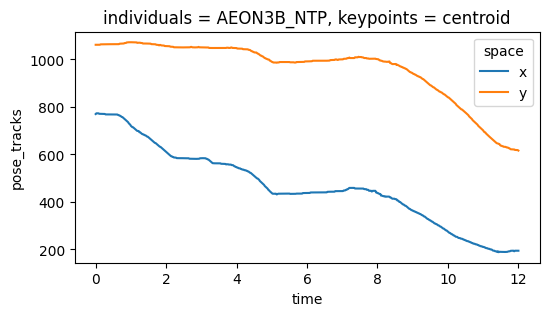

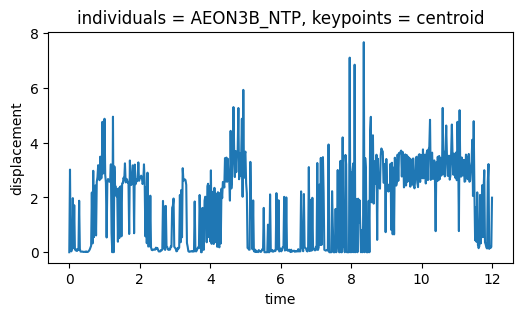

In [141]:
ds0 = ds.sel(individuals="AEON3B_NTP", keypoints="centroid")
ds0["pose_tracks"].plot.line(x="time", hue='space', aspect=2, size=3);
ds0['displacement'].plot.line(x='time', aspect=2, size=3);

In [143]:
ds["velocity"] = kinematics.velocity(ds["pose_tracks"])
ds["acceleration"] = kinematics.acceleration(ds["pose_tracks"])
ds["speed"] = kinematics.velocity_vector(ds["pose_tracks"])["magnitude"]
ds

<xarray.Dataset>
Dimensions:       (time: 601, individuals: 3, keypoints: 1, space: 2)
Coordinates:
  * time          (time) float64 0.0 0.02 0.04 0.06 ... 11.94 11.96 11.98 12.0
  * individuals   (individuals) <U10 'AEON3B_NTP' 'AEON3B_TP1' 'AEON3B_TP2'
  * keypoints     (keypoints) <U8 'centroid'
  * space         (space) <U1 'x' 'y'
Data variables:
    pose_tracks   (time, individuals, keypoints, space) float32 770.3 ... 755.1
    confidence    (time, individuals, keypoints) float32 nan nan nan ... nan nan
    displacement  (time, individuals, keypoints) float32 0.0 0.0 ... 2.872 3.495
    velocity      (time, individuals, keypoints, space) float32 150.8 ... -158.8
    acceleration  (time, individuals, keypoints, space) float32 -3.704e+03 .....
    speed         (time, individuals, keypoints) float32 150.8 118.9 ... 174.7
Attributes:
    fps:              50.0
    time_unit:        seconds
    source_software:  SLEAP
    source_file:      /Users/nsirmpilatze/.movement/data/poses/SLEAP_three-mi...

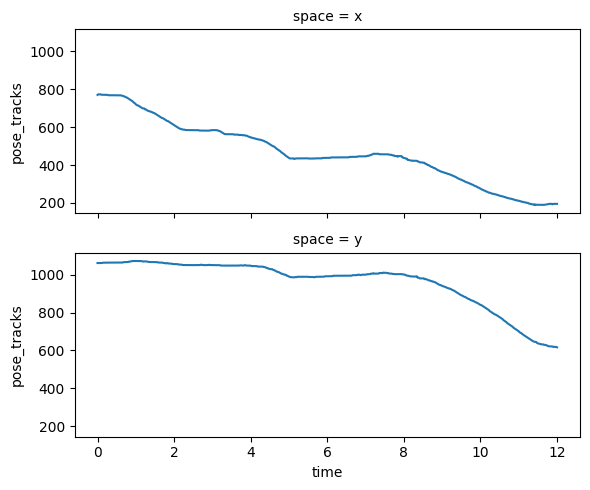

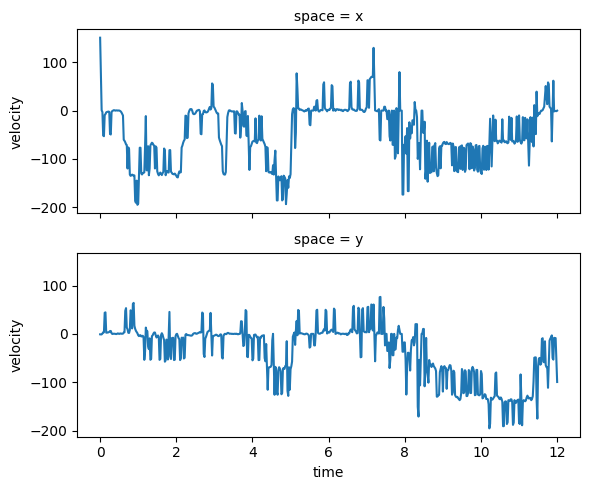

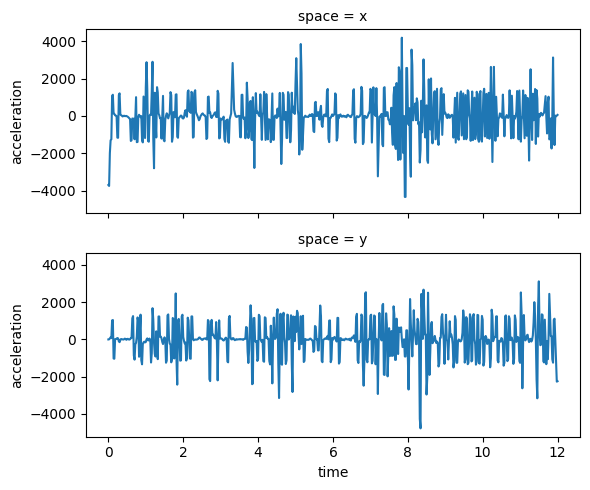

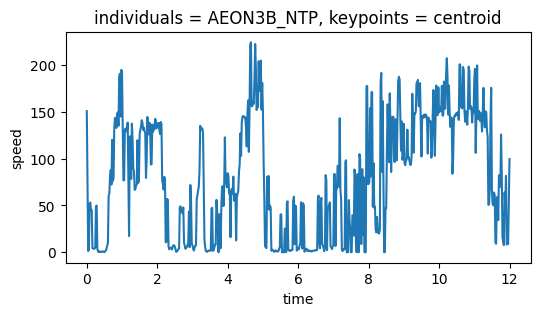

In [146]:
ds0 = ds.sel(individuals="AEON3B_NTP", keypoints="centroid")
ds0['pose_tracks'].plot.line(x='time', row='space', aspect=2, size=2.5)
ds0['velocity'].plot.line(x='time', row='space', aspect=2, size=2.5)
ds0['acceleration'].plot.line(x='time', row='space', aspect=2, size=2.5)
ds0['speed'].plot.line(x='time', aspect=2, size=3)